# R09-H61 - hub truncation: uniform render caps on a heavy-tailed graph

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-06 <br>
**Pipeline stage**: R09 graph topology round, render family (feeds H78/H79) <br>
**Graph**: rebuilt CPAP graph (neo4j2), 28-probe gold set <br>

H67 measured that 91% of golds sit ON a production seed yet H34 measured only 63.6% appearing
in the vec-channel render - the loss is in rendering, not reach. This notebook decomposes that
gap and tests the registered claim: the uniform LIMIT 15 relation cap silently discards gold
on high-degree nodes, and a matched-budget re-ranking recovers it.

## Approach
1. **Degree census** - distribution over valid non-SIMILAR_TO edges; how far the top decile
   exceeds the cap
2. **Gap decomposition** - for each gold: carrier in vec-8 seeds? if yes, which surface
   component carries it - base render (desc/props), first-15 relations, TRUNCATED relations
   (16+), or attached propositions the prop channel happens not to seed
3. **Matched-budget re-rank** - same 15 lines per node, chosen by policy instead of storage
   order: neighbor-degree ascending (periphery first) and type-entropy round-robin (rare
   relation types first - the H79 interim test); Pareto check that no previously-present gold drops

## Outputs
- `reports/probe-render-r09h61-<stamp>.json` - degree stats, decomposition, recovery matrix
- In-notebook: log-log degree histogram, decomposition bar, verdict

In [1]:
# Imports
# stdlib
import datetime  # report stamps
import json  # report persistence
import os  # graph selection env
import re  # evidence normalization
from collections import Counter  # entropy ranking

# third party
import numpy as np  # degree stats
import yaml  # probe set
import matplotlib.pyplot as plt  # figures
from pathlib import Path
from rich import print as rprint  # semantic output
from rich.progress import Progress  # audit loop

os.environ["NEO4J_URI"] = "bolt://user-konrad.jelen-kgf-neo4j2:7687"
os.environ["NEO4J_USER"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "kgfoundry"

# project
from knowledge_graph_foundry import Foundry, load_settings  # pipeline
from knowledge_graph_foundry.extraction import generate_embeddings  # Titan probe embedding
from knowledge_graph_foundry.graph.graphrag import vector_query  # seed channel
from knowledge_graph_foundry.models import Entity  # embedding probe wrapper

2026-07-06 21:54:03.766 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


In [2]:
# Configuration
PROBES_PATH = Path("../tests/probes/cpap-probe-set.yml")

settings = load_settings(Path("../config.yml"))
TOP_K = settings.graphrag.top_k                 # production vector seeds (8)
VEC_INDEX = settings.graphrag.vector_index_name
REL_LIMIT = 15                                  # production per-node relation cap
ALIAS_LIMIT = 5                                 # production alias cap

# pre-registered acceptance bar (experiments log, R09-H61)
BAR_HUB_RATIO = 3      # top-decile degree >= 3x the cap
BAR_TRUNC_PROBES = 2   # >=2 probes with gold in truncated relations on a hub
# recovery clause: matched-budget re-rank recovers them, Pareto (no present gold lost)

probes = yaml.safe_load(PROBES_PATH.read_text())
gold_probes = [p for p in probes if p.get("gold_evidence")]

rprint(f"""[bold cyan]Configuration[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
[bold]Graph[/bold]
  Neo4j: [cyan]{os.environ['NEO4J_URI']}[/cyan]

[bold]Render (production)[/bold]
  Vector top-k: [yellow]{TOP_K}[/yellow]  Relation cap: [yellow]{REL_LIMIT}[/yellow]  Alias cap: [yellow]{ALIAS_LIMIT}[/yellow]

[bold]Acceptance bar[/bold]
  Hubs: top-decile degree >= [yellow]{BAR_HUB_RATIO}x[/yellow] cap
  Truncation: >= [yellow]{BAR_TRUNC_PROBES}[/yellow] probes lose gold to relation truncation
  Recovery: matched-budget re-rank, Pareto over storage order
  Probes: [yellow]{len(gold_probes)}[/yellow] with gold evidence
""")

Configuration
────────────────────────────────────────
Graph
  Neo4j: bolt://user-konrad.jelen-kgf-neo4j2:7687

Render (production)
  Vector top-k: 8  Relation cap: 15  Alias cap: 5

Acceptance bar
  Hubs: top-decile degree >= 3x cap
  Truncation: >= 2 probes lose gold to relation truncation
  Recovery: matched-budget re-rank, Pareto over storage order
  Probes: 24 with gold evidence

## Degree census

Degree over currently-valid non-SIMILAR_TO edges. The render cap is a horizontal line
through this distribution: every node above it renders an arbitrary 15-subset of its
relations.

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=40, offset=39>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 39, 'line': 1, 'column': 40}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (e:Entity)-[r]-(:Entity) WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' RETURN e.id AS id, count(r) AS deg"


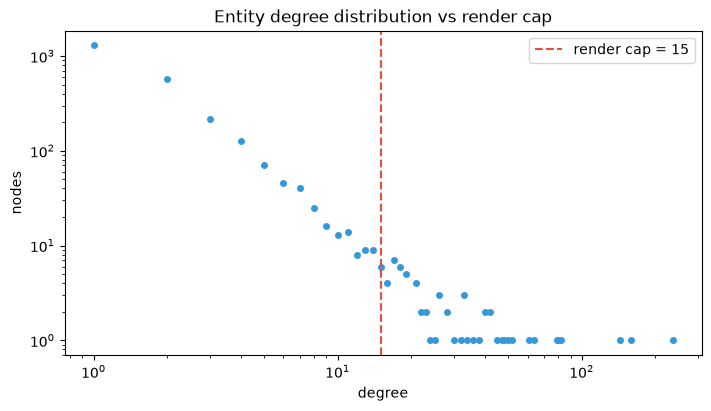

nodes with edges: 2531  median: 1  p90: 5  max: 236
over cap (15): 62 nodes (2.4%)  top-decile mean: 13.5 = 0.9x cap (bar 3x)

In [3]:
with Foundry(settings) as f:
    with f.driver.session() as s:
        deg_rows = s.run(
            "MATCH (e:Entity)-[r]-(:Entity) "
            "WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' "
            "RETURN e.id AS id, count(r) AS deg"
        ).data()

degree = {r["id"]: r["deg"] for r in deg_rows}
degs = np.array(sorted(degree.values()))
d90 = float(np.percentile(degs, 90))
over_cap = int((degs > REL_LIMIT).sum())
top_decile_mean = float(degs[degs >= d90].mean())

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
vals, counts = np.unique(degs, return_counts=True)
ax.loglog(vals, counts, "o", color="#3498DB", markersize=4)
ax.axvline(REL_LIMIT, color="#E74C3C", linestyle="--", label=f"render cap = {REL_LIMIT}")
ax.set(xlabel="degree", ylabel="nodes", title="Entity degree distribution vs render cap")
ax.legend()
plt.show()

rprint(
    f"nodes with edges: [yellow]{len(degs)}[/yellow]  median: [yellow]{np.median(degs):.0f}[/yellow]  "
    f"p90: [yellow]{d90:.0f}[/yellow]  max: [yellow]{degs.max()}[/yellow]\n"
    f"over cap ({REL_LIMIT}): [yellow]{over_cap}[/yellow] nodes "
    f"([dim]{over_cap / len(degs):.1%}[/dim])  top-decile mean: [yellow]{top_decile_mean:.1f}[/yellow] "
    f"= [yellow]{top_decile_mean / REL_LIMIT:.1f}x[/yellow] cap [dim](bar {BAR_HUB_RATIO}x)[/dim]"
)

## Gap decomposition per gold

For each gold, against the vec-8 seed set: SEEDING gap (no carrier among the 8 seeds) vs
render placement - BASE (desc/props/alias merge), REL<=15 (rendered relations), REL-TRUNC
(relation lines 16+, discarded by the cap), PROP-ATTACHED (only in a proposition attached to
the seed, invisible unless the proposition channel independently retrieves it).

In [4]:
def _norm(s):
    return re.sub(r"\s+", " ", s.casefold())


def value_tokens(text):
    return re.findall(r"[\w.\-/]*\d[\w.\-/]*", text)


_UNIT = r"(?<=\d)\s*(mm|cm|dba|db\(a\)|db|kg|g|oz|ml|l|w|hz|mins|min|m)\b"


def present(gold, ctx_norm):
    ng = _norm(gold)
    if ng in ctx_norm:
        return True
    squashed = re.sub(r"[\s,()]", "", ctx_norm)
    skeleton = re.sub(r"[\s,()]", "", re.sub(_UNIT, "", ng))
    if any(ch.isdigit() for ch in skeleton) and len(skeleton) >= 5 and skeleton in squashed:
        return True
    tokens = value_tokens(gold)
    if tokens:
        hit = sum(1 for t in tokens if _norm(t) in ctx_norm or re.sub(r"[\s,()]", "", _norm(t)) in squashed)
        return hit >= max(1, len(tokens) // 2 + (len(tokens) % 2))
    words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ng))
    ctx_words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ng if False else ctx_norm))
    return bool(words) and len(words & ctx_words) / len(words) >= 0.6


REL_CACHE, BASE_CACHE, PROP_CACHE = {}, {}, {}


def node_parts(session, nid):
    if nid not in REL_CACHE:
        row = session.run(
            "MATCH (e:Entity {id: $id}) RETURN e.name AS name, labels(e) AS types, "
            "e.description AS description, properties(e) AS props", id=nid).single()
        spec = {k.removeprefix("prop_"): v for k, v in row["props"].items() if k.startswith("prop_")}
        aliases = session.run(
            "MATCH (e:Entity {id: $id})-[:SAME_AS*1..2]-(a:Entity) WHERE a.id <> $id "
            "RETURN DISTINCT a.name AS name, properties(a) AS props LIMIT 5", id=nid).data()
        for a in aliases:
            for k, v in a["props"].items():
                if k.startswith("prop_"):
                    spec.setdefault(k.removeprefix("prop_"), v)
        BASE_CACHE[nid] = (
            f"## {row['name']} ({', '.join(row['types'])})\n"
            + (f"Also known as: {', '.join(a['name'] for a in aliases)}\n" if aliases else "")
            + f"{row['description'] or ''}\nProperties: {json.dumps(spec, default=str)}"
        )
        REL_CACHE[nid] = session.run(
            "MATCH (e:Entity {id: $id})-[r]-(n:Entity) "
            "WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' "
            "RETURN type(r) AS rel, n.name AS name, n.id AS nid", id=nid).data()
        PROP_CACHE[nid] = [r["t"] for r in session.run(
            "MATCH (p:Proposition)-[:ABOUT]->(e:Entity {id: $id}) RETURN p.text AS t", id=nid)]
    return BASE_CACHE[nid], REL_CACHE[nid], PROP_CACHE[nid]


def rel_line(r):
    return f"{r['rel']} -> {r['name']}"


decomp = []
seed_sets = {}
with Foundry(settings) as f, Progress() as progress:
    task = progress.add_task("decomposition", total=len(gold_probes))
    for p in gold_probes:
        q_ = p["question"]
        probe_e = Entity.create(q_[:80], types=["Query"], description=q_)
        emb = generate_embeddings([probe_e], settings.embeddings)[0].embedding
        seed_ids = [s_["id"] for s_ in vector_query(f.driver, emb, VEC_INDEX, top_k=TOP_K)]
        seed_sets[p["id"]] = seed_ids

        with f.driver.session() as session:
            parts = {nid: node_parts(session, nid) for nid in seed_ids}

        for g in p["gold_evidence"]:
            placement = "SEEDING"   # no vec-8 carrier at all
            hub_nid = None
            for nid in seed_ids:
                base, rels, props_ = parts[nid]
                if present(g, _norm(base)):
                    placement = "BASE"; break
                head = " ; ".join(rel_line(r) for r in rels[:REL_LIMIT])
                if present(g, _norm(base + " " + head)):
                    placement = "REL<=15"; break
                tail = " ; ".join(rel_line(r) for r in rels[REL_LIMIT:])
                if tail and present(g, _norm(base + " " + tail)):
                    placement = "REL-TRUNC"; hub_nid = nid; break
                if props_ and present(g, _norm(" ".join(props_))):
                    placement = "PROP-ATTACHED"; hub_nid = nid; break
            decomp.append({"probe": p["id"], "gold": g[:70], "placement": placement,
                           "hub": hub_nid, "hub_degree": degree.get(hub_nid) if hub_nid else None})
        progress.advance(task)

counts = Counter(d["placement"] for d in decomp)
rprint(f"[bold cyan]Gap decomposition[/bold cyan] (33 golds vs vec-8 seeds): {dict(counts)}")
for d in decomp:
    if d["placement"] in ("REL-TRUNC", "PROP-ATTACHED"):
        rprint(f"  [dim]{d['probe']}[/dim] [red]{d['placement']}[/red] "
               f"(deg {d['hub_degree']}): {d['gold']}")

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

2026-07-06 21:54:04.868 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-06 21:54:04.870 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key
does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', 
position=<SummaryInputPosition line=1, column=51, offset=50>, raw_classification='UNRECOGNIZED', 
classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', 
severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', 
'_severity': 'WARNING', '_position': {'offset': 50, 'line': 1, 'column': 51}, 'OPERATION': '', 'OPERATION_CODE': 
'0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (e:Entity {id: $id})-[r]-(n:Entity) WHERE r.valid_to IS NULL AND 
type(r) <> 'SIMILAR_TO' RETURN type(r) AS rel, n.name AS name, n.id AS nid"

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key
does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', 
position=<SummaryInputPosition line=1, column=51, offset=50>, raw_classification='UNRECOGNIZED', 
classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', 
severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', 
'_severity': 'WARNING', '_position': {'offset': 50, 'line': 1, 'column': 51}, 'OPERATION': '', 'OPERATION_CODE': 
'0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (e:Entity {id: $id})-[r]-(n:Entity) WHERE r.valid_to IS NULL AND 
type(r) <> 'SIMILAR_TO' RETURN type(r) AS rel, n.name AS name, n.id AS nid"

...

P10 PROP-ATTACHED (deg 2): SD card: > 1 year

P12 PROP-ATTACHED (deg 1): 26 dB(A)

P19 PROP-ATTACHED (deg 3): constant lower pressure

P23 PROP-ATTACHED (deg 3): sleep onset detection

P24 PROP-ATTACHED (deg 1): reduces the pressure during expiration

## Matched-budget re-rank and verdict

Same 15 relation lines per node - zero budget change - chosen by policy instead of storage
order: **neighbor-degree ascending** (periphery neighbors first; spec values and components
are low-degree, generic categories are hubs) and **type-entropy round-robin** (rare relation
types first - the H79 interim policy). Pareto clause: every gold present under storage order
must stay present.

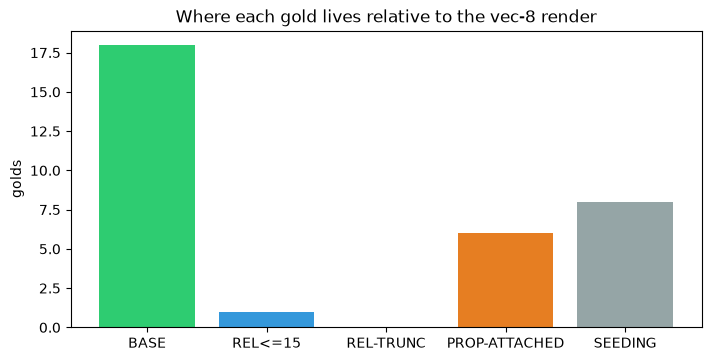

H61 verdict
────────────────────────────────────────
  Hub clause: top-decile mean 13.5 vs 3x cap = 45 -> False
  Truncation-loss probes: 0 (bar >= 2)
  Re-rank presence (of 33): storage 23, neighbor-degree 23, entropy 23
  Best policy neighbor_degree: recovered 0, lost 0 (Pareto: True)
  Verdict: REFUTED

saved ../reports/probe-render-r09h61-20260706-195411.json

In [5]:
def rank_neighbor_degree(rels):
    return sorted(rels, key=lambda r: degree.get(r["nid"], 0))


def rank_entropy(rels):
    by_type = {}
    for r in rels:
        by_type.setdefault(r["rel"], []).append(r)
    ordered_types = sorted(by_type, key=lambda t: len(by_type[t]))
    out, i = [], 0
    while len(out) < len(rels):
        for t in ordered_types:
            if i < len(by_type[t]):
                out.append(by_type[t][i])
        i += 1
    return out


POLICIES = {"storage": lambda r: r, "neighbor_degree": rank_neighbor_degree, "entropy": rank_entropy}

recovery = {k: {"present": 0, "lost": [], "recovered": []} for k in POLICIES}
for p in gold_probes:
    seed_ids = seed_sets[p["id"]]
    for g in p["gold_evidence"]:
        base_placement = next(d for d in decomp if d["probe"] == p["id"] and d["gold"] == g[:70])
        for pol, fn in POLICIES.items():
            found = False
            for nid in seed_ids:
                base, rels, _ = BASE_CACHE[nid], REL_CACHE[nid], None
                head = " ; ".join(rel_line(r) for r in fn(list(rels))[:REL_LIMIT])
                if present(g, _norm(base + " " + head)):
                    found = True
                    break
            if found:
                recovery[pol]["present"] += 1
                if base_placement["placement"] == "REL-TRUNC" and pol != "storage":
                    recovery[pol]["recovered"].append((p["id"], g[:50]))
            elif base_placement["placement"] in ("BASE", "REL<=15") and pol != "storage":
                recovery[pol]["lost"].append((p["id"], g[:50]))

n_trunc_probes = len({d["probe"] for d in decomp if d["placement"] == "REL-TRUNC"})
hub_bar_met = top_decile_mean >= BAR_HUB_RATIO * REL_LIMIT
best_pol = max((k for k in POLICIES if k != "storage"),
               key=lambda k: (len(recovery[k]["recovered"]), -len(recovery[k]["lost"])))
pareto = not recovery[best_pol]["lost"]
recovered_n = len(recovery[best_pol]["recovered"])

if n_trunc_probes >= BAR_TRUNC_PROBES and recovered_n > 0 and pareto:
    verdict = "CONFIRMED"
elif n_trunc_probes == 0:
    verdict = "REFUTED"
else:
    verdict = "PARTIAL"

fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
order_p = ["BASE", "REL<=15", "REL-TRUNC", "PROP-ATTACHED", "SEEDING"]
ax.bar(order_p, [counts.get(k, 0) for k in order_p],
       color=["#2ECC71", "#3498DB", "#E74C3C", "#E67E22", "#95A5A6"])
ax.set(ylabel="golds", title="Where each gold lives relative to the vec-8 render")
plt.show()

rprint(f"""[bold cyan]H61 verdict[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Hub clause: top-decile mean [yellow]{top_decile_mean:.1f}[/yellow] vs {BAR_HUB_RATIO}x cap = {BAR_HUB_RATIO * REL_LIMIT} -> [{'green' if hub_bar_met else 'red'}]{hub_bar_met}[/]
  Truncation-loss probes: [yellow]{n_trunc_probes}[/yellow] [dim](bar >= {BAR_TRUNC_PROBES})[/dim]
  Re-rank presence (of 33): storage [yellow]{recovery['storage']['present']}[/yellow], neighbor-degree [yellow]{recovery['neighbor_degree']['present']}[/yellow], entropy [yellow]{recovery['entropy']['present']}[/yellow]
  Best policy [cyan]{best_pol}[/cyan]: recovered [green]{recovered_n}[/green], lost [red]{len(recovery[best_pol]['lost'])}[/red] (Pareto: {pareto})
  Verdict: [{'green' if verdict == 'CONFIRMED' else 'red'}]{verdict}[/]
""")
for pol in ("neighbor_degree", "entropy"):
    for pid, g in recovery[pol]["lost"]:
        rprint(f"  [red]{pol} lost[/red] [dim]{pid}[/dim] {g}")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"probe-render-r09h61-{stamp}.json"
out.write_text(json.dumps({
    "degree": {"n": int(len(degs)), "median": float(np.median(degs)), "p90": d90,
               "max": int(degs.max()), "over_cap": over_cap, "top_decile_mean": top_decile_mean},
    "decomposition": dict(counts), "detail": decomp,
    "recovery": {k: {"present": v["present"], "recovered": v["recovered"], "lost": v["lost"]}
                 for k, v in recovery.items()},
    "verdict": verdict,
}, indent=2, default=str))
rprint("saved", str(out))